In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Mengabaikan pesan warning agar notebook terlihat bersih
warnings.filterwarnings('ignore')

# Mengatur tema visual grafik portofolio (estetis)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Membaca data (ganti 'telco_cleaned.csv' sesuai nama file Anda yang di-upload ke Colab)
df = pd.read_csv('/content/drive/MyDrive/Customer Churn/telco_cleaned.csv')

# Menampilkan 5 baris pertama untuk inspeksi
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,Churn,TenureGroup,ChargeSegment,AutoPayFlag,TotalAddOns,HasProtectionBundle,ChurnFlag,ChargeLogicValidation
0,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No,...,19.70,0.0,No,1. 0-12 Bulan (Baru),Low Value,Manual Pay,0,No,0,Normal
1,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No,...,19.85,0.0,No,1. 0-12 Bulan (Baru),Low Value,Manual Pay,0,No,0,Normal
2,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No,...,20.00,0.0,No,1. 0-12 Bulan (Baru),Low Value,Manual Pay,0,No,0,Normal
3,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No,...,20.25,0.0,No,1. 0-12 Bulan (Baru),Low Value,Manual Pay,0,No,0,Normal
4,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No,...,25.35,0.0,No,1. 0-12 Bulan (Baru),Low Value,Manual Pay,0,No,0,Normal


**Data Profiling**

In [21]:
print("=== INFO STRUKTUR DATA ===")
df.info()
print("\n" + "="*50 + "\n")

print("=== PENGECEKAN MISSING VALUES ===")
# Seharusnya menghasilkan 0 semua karena sudah ditangani COALESCE di SQL
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

print("=== RINGKASAN STATISTIK NUMERIK (MIN/MAX/MEAN) ===")
# Mengecek ringkasan kolom angka
display(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalAddOns']].describe().round(2))

=== INFO STRUKTUR DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             7043 non-null   object 
 1   gender                 7043 non-null   object 
 2   SeniorCitizen          7043 non-null   object 
 3   Partner                7043 non-null   object 
 4   Dependents             7043 non-null   object 
 5   tenure                 7043 non-null   int64  
 6   PhoneService           7043 non-null   object 
 7   MultipleLines          7043 non-null   object 
 8   InternetService        7043 non-null   object 
 9   OnlineSecurity         7043 non-null   object 
 10  OnlineBackup           7043 non-null   object 
 11  DeviceProtection       7043 non-null   object 
 12  TechSupport            7043 non-null   object 
 13  StreamingTV            7043 non-null   object 
 14  StreamingMovies        7043 n

,tenure,MonthlyCharges,TotalCharges,TotalAddOns
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,2.04
std,24.56,30.09,2266.79,1.85
min,0.00,18.25,0.00,0.00
25%,9.00,35.50,398.55,0.00
50%,29.00,70.35,1394.55,2.00
75%,55.00,89.85,3786.60,3.00
max,72.00,118.75,8684.80,6.00


**Class Balance (Target Variabel)**

Proporsi Churn:
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


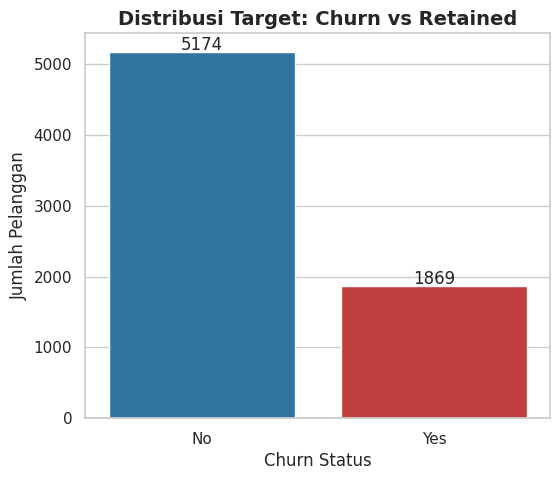

In [22]:
# Menghitung proporsi
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Proporsi Churn:\n", churn_pct.round(2))

# Visualisasi Imbalance Data
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='Churn', palette=['#1f77b4', '#d62728'])
plt.title('Distribusi Target: Churn vs Retained', fontweight='bold', fontsize=14)
plt.ylabel('Jumlah Pelanggan')
plt.xlabel('Churn Status')

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

**Univariated Analysis Numerik** tenure, MonthlyCharges, dan TotalCharges

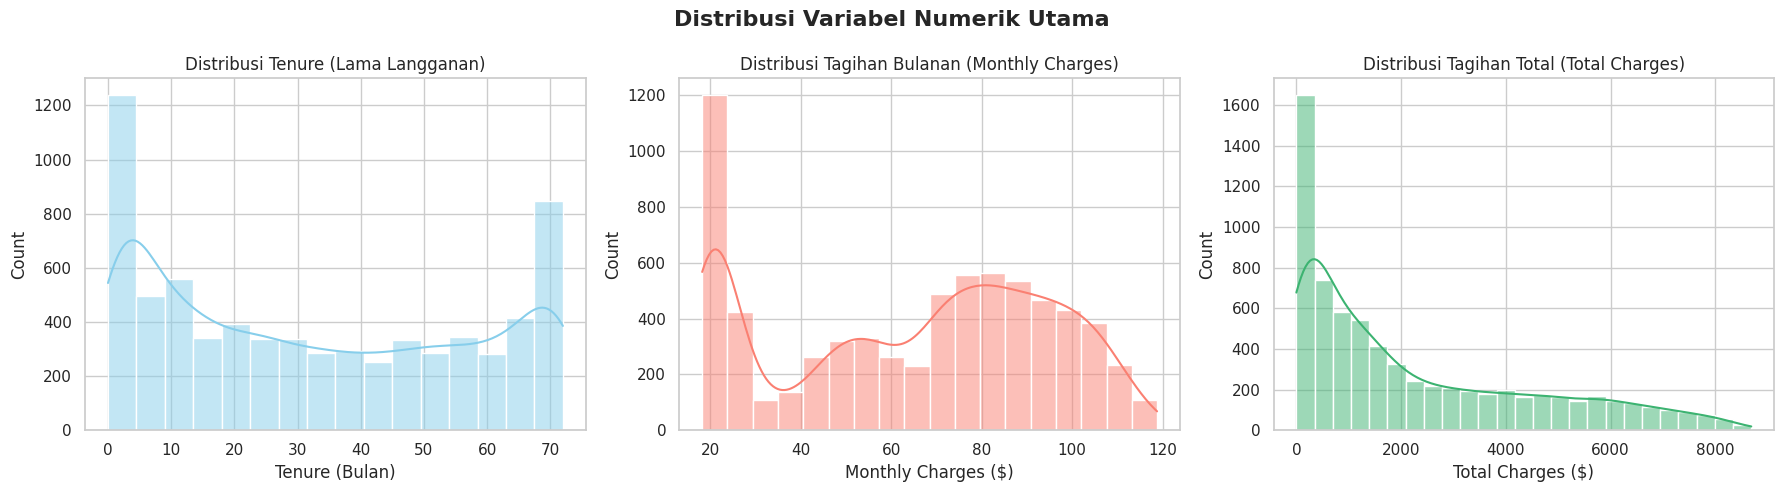

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Variabel Numerik Utama', fontweight='bold', fontsize=16)

# 1. Distribusi Tenure
sns.histplot(df['tenure'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Tenure (Lama Langganan)')
axes[0].set_xlabel('Tenure (Bulan)')

# 2. Distribusi Monthly Charges
sns.histplot(df['MonthlyCharges'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribusi Tagihan Bulanan (Monthly Charges)')
axes[1].set_xlabel('Monthly Charges ($)')

# 3. Distribusi Total Charges
sns.histplot(df['TotalCharges'], kde=True, color='mediumseagreen', ax=axes[2])
axes[2].set_title('Distribusi Tagihan Total (Total Charges)')
axes[2].set_xlabel('Total Charges ($)')

plt.tight_layout()
plt.show()

**Univariate Analysis - Kategorik**
Distribusi fitur hasil Feature Engineering (Tenure Group & Charge Segment)

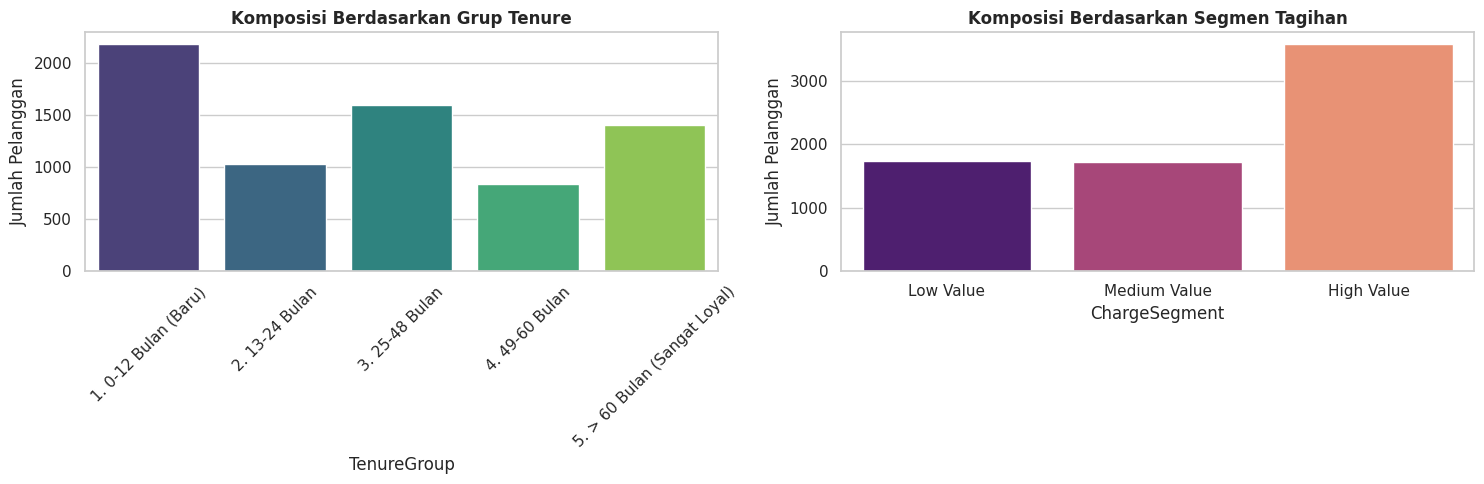

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribusi Tenure Group
sns.countplot(data=df, x='TenureGroup', palette='viridis', order=sorted(df['TenureGroup'].unique()), ax=axes[0])
axes[0].set_title('Komposisi Berdasarkan Grup Tenure', fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].tick_params(axis='x', rotation=45)

# 2. Distribusi Charge Segment
sns.countplot(data=df, x='ChargeSegment', palette='magma', order=['Low Value', 'Medium Value', 'High Value'], ax=axes[1])
axes[1].set_title('Komposisi Berdasarkan Segmen Tagihan', fontweight='bold')
axes[1].set_ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

**Bivariate Analysis - Driver Utama (Kontrak, Tenure, & Internet)**
Melihat persentase churn berdasarkan fitur-fitur yang paling krusial secara bisnis

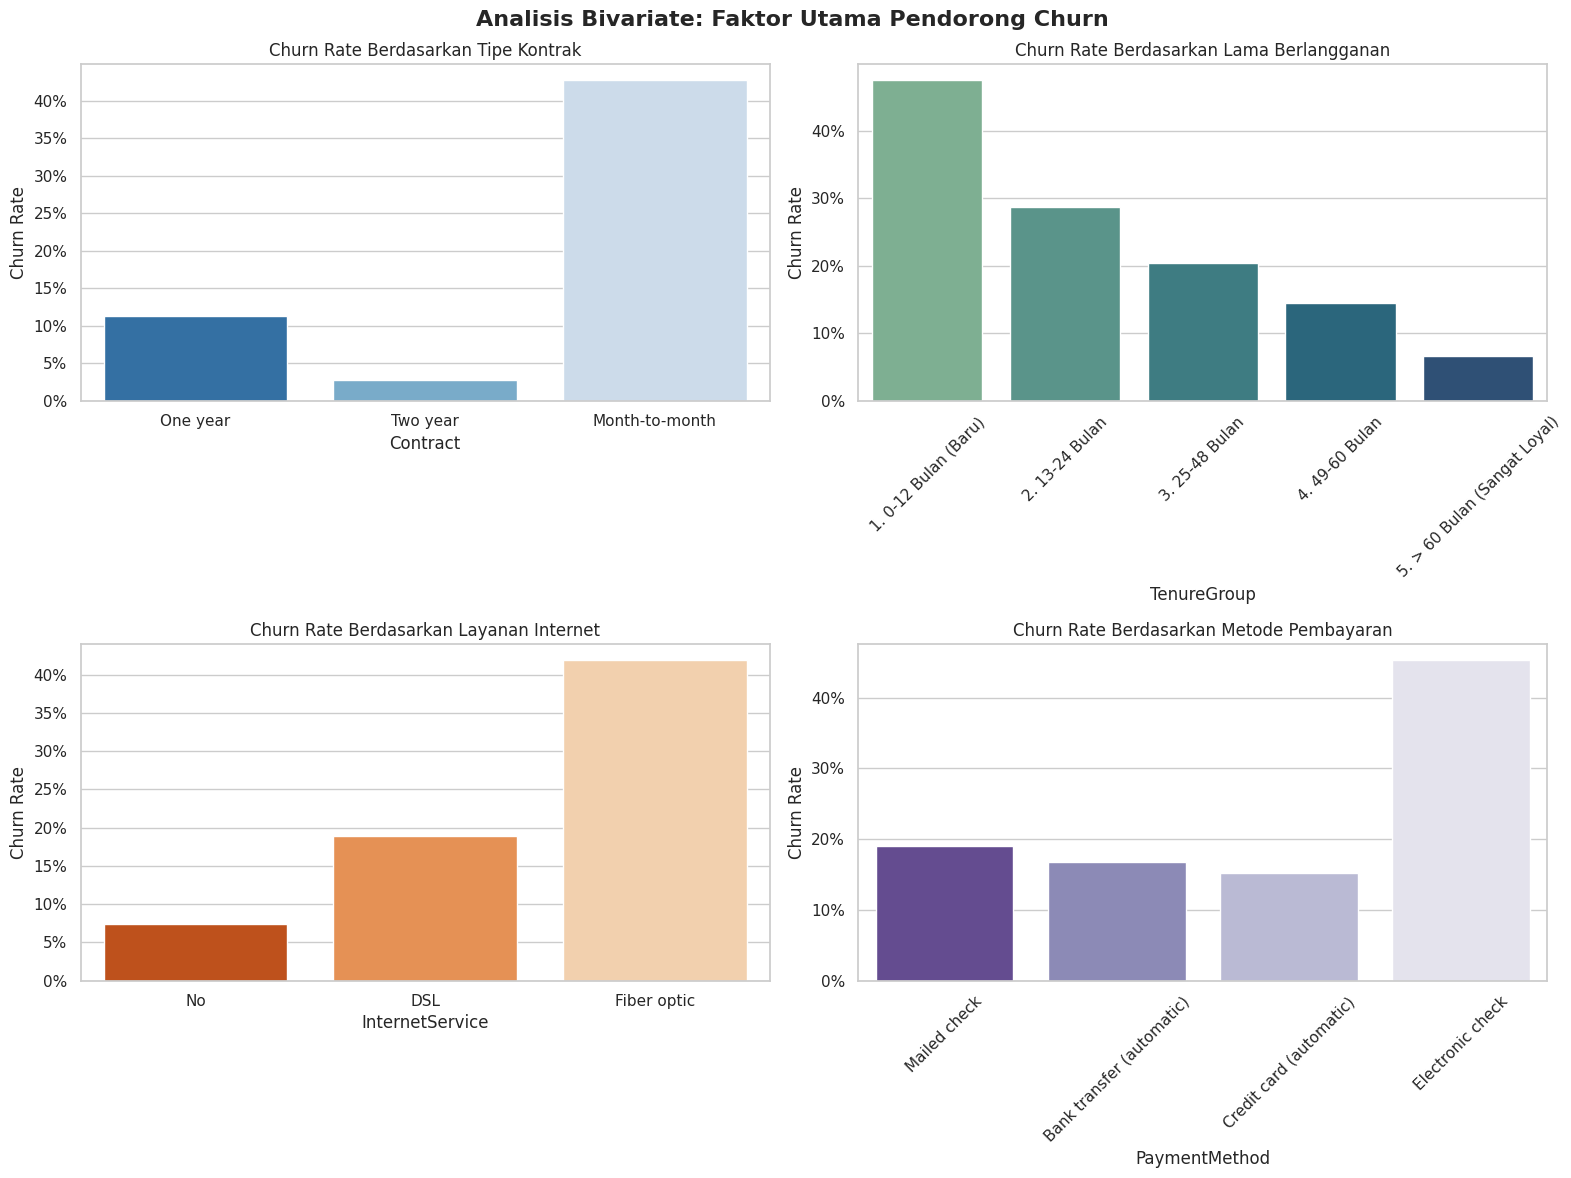

In [25]:
# Memastikan kolom ChurnFlag tersedia untuk perhitungan persentase
if 'ChurnFlag' not in df.columns:
    df['ChurnFlag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Membuat grid 2x2 untuk visualisasi
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Bivariate: Faktor Utama Pendorong Churn', fontweight='bold', fontsize=16)

# 1. Churn Rate vs Contract
sns.barplot(data=df, x='Contract', y='ChurnFlag', ax=axes[0, 0], palette='Blues_r', ci=None)
axes[0, 0].set_title('Churn Rate Berdasarkan Tipe Kontrak')
axes[0, 0].set_ylabel('Churn Rate')
axes[0, 0].set_yticklabels(['{:,.0%}'.format(x) for x in axes[0, 0].get_yticks()])

# 2. Churn Rate vs Tenure Group
sns.barplot(data=df, x='TenureGroup', y='ChurnFlag', ax=axes[0, 1], palette='crest', ci=None,
            order=sorted(df['TenureGroup'].unique()))
axes[0, 1].set_title('Churn Rate Berdasarkan Lama Berlangganan')
axes[0, 1].set_ylabel('Churn Rate')
axes[0, 1].set_yticklabels(['{:,.0%}'.format(x) for x in axes[0, 1].get_yticks()])
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Churn Rate vs Internet Service
sns.barplot(data=df, x='InternetService', y='ChurnFlag', ax=axes[1, 0], palette='Oranges_r', ci=None)
axes[1, 0].set_title('Churn Rate Berdasarkan Layanan Internet')
axes[1, 0].set_ylabel('Churn Rate')
axes[1, 0].set_yticklabels(['{:,.0%}'.format(x) for x in axes[1, 0].get_yticks()])

# 4. Churn Rate vs Payment Method
sns.barplot(data=df, x='PaymentMethod', y='ChurnFlag', ax=axes[1, 1], palette='Purples_r', ci=None)
axes[1, 1].set_title('Churn Rate Berdasarkan Metode Pembayaran')
axes[1, 1].set_ylabel('Churn Rate')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_yticklabels(['{:,.0%}'.format(x) for x in axes[1, 1].get_yticks()])

plt.tight_layout()
plt.show()

**Bivariate Analysis - Efek Ekosistem (Layanan Tambahan)**
Uji hipotesis Feature Engineering kita: Apakah layanan pelindung mengikat pelanggan?

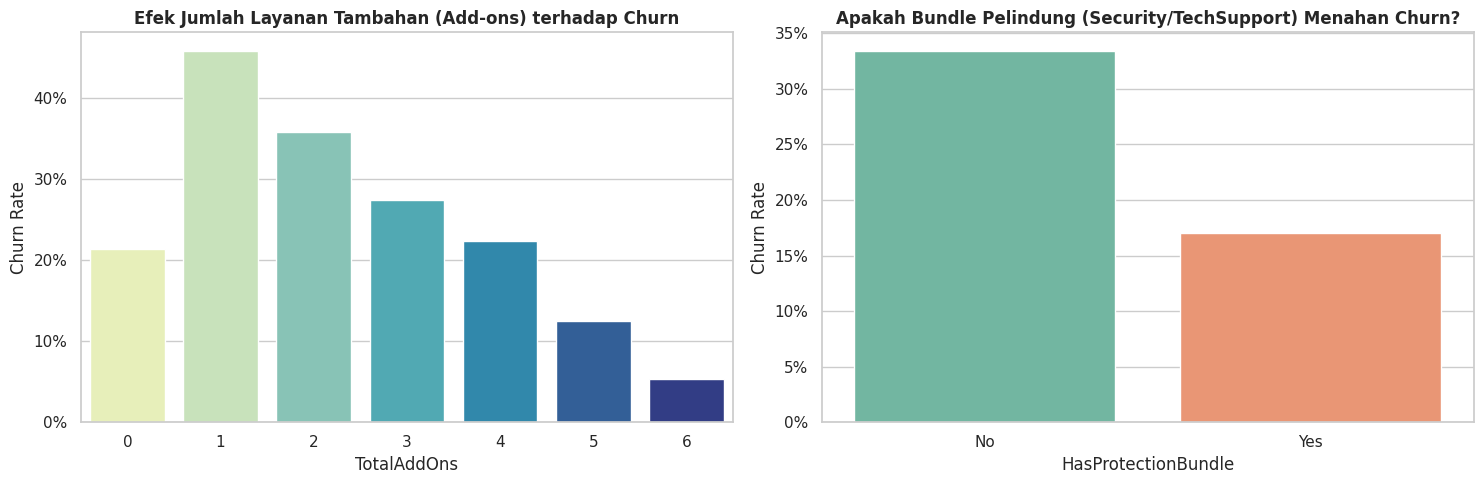

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Churn Rate vs Total Add-ons
sns.barplot(data=df, x='TotalAddOns', y='ChurnFlag', ax=axes[0], palette='YlGnBu', ci=None)
axes[0].set_title('Efek Jumlah Layanan Tambahan (Add-ons) terhadap Churn', fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_yticklabels(['{:,.0%}'.format(x) for x in axes[0].get_yticks()])

# 2. Churn Rate vs Has Protection Bundle
sns.barplot(data=df, x='HasProtectionBundle', y='ChurnFlag', ax=axes[1], palette='Set2', ci=None)
axes[1].set_title('Apakah Bundle Pelindung (Security/TechSupport) Menahan Churn?', fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].set_yticklabels(['{:,.0%}'.format(x) for x in axes[1].get_yticks()])

plt.tight_layout()
plt.show()

**Bivariate Analysis - Beban Finansial** Menganalisis distribusi harga tagihan menggunakan Boxplot untuk melihat perbedaan profil bayar antara yang menetap dan yang pergi

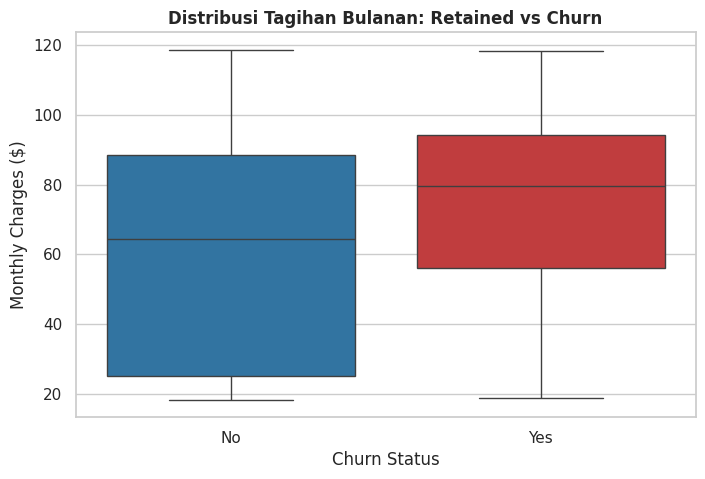

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#1f77b4', '#d62728'])
plt.title('Distribusi Tagihan Bulanan: Retained vs Churn', fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.show()

**Multivariate Analysis - Segmen Berisiko Tinggi (Heatmap)**
Gabungkan 3 variabel sekaligus (TenureGroup, Contract, dan Churn Rate) untuk memetakan "Zona Merah" bisnis

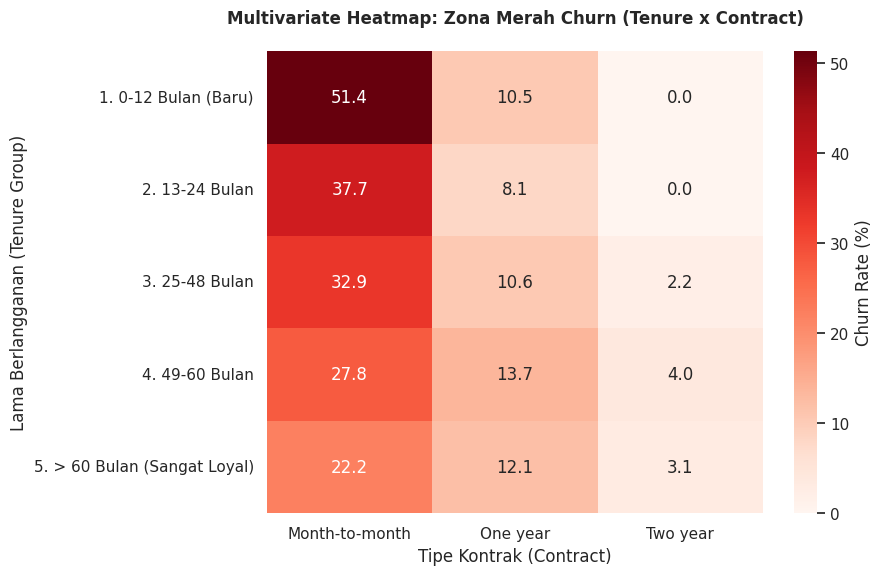

In [28]:
# Membuat Pivot Table untuk Heatmap
heatmap_data = pd.pivot_table(df, values='ChurnFlag',
                              index='TenureGroup',
                              columns='Contract',
                              aggfunc='mean') * 100 # Dikali 100 untuk %

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Multivariate Heatmap: Zona Merah Churn (Tenure x Contract)', fontweight='bold', pad=20)
plt.ylabel('Lama Berlangganan (Tenure Group)')
plt.xlabel('Tipe Kontrak (Contract)')
plt.show()

### Multivariate Heatmap: Zona Merah Churn (Tenure x Contract x InternetService)

Memperluas analisis "zona merah" dengan menambahkan dimensi `InternetService`. Kita akan melihat bagaimana kombinasi `TenureGroup` dan `Contract` mempengaruhi churn rate untuk setiap jenis layanan internet.

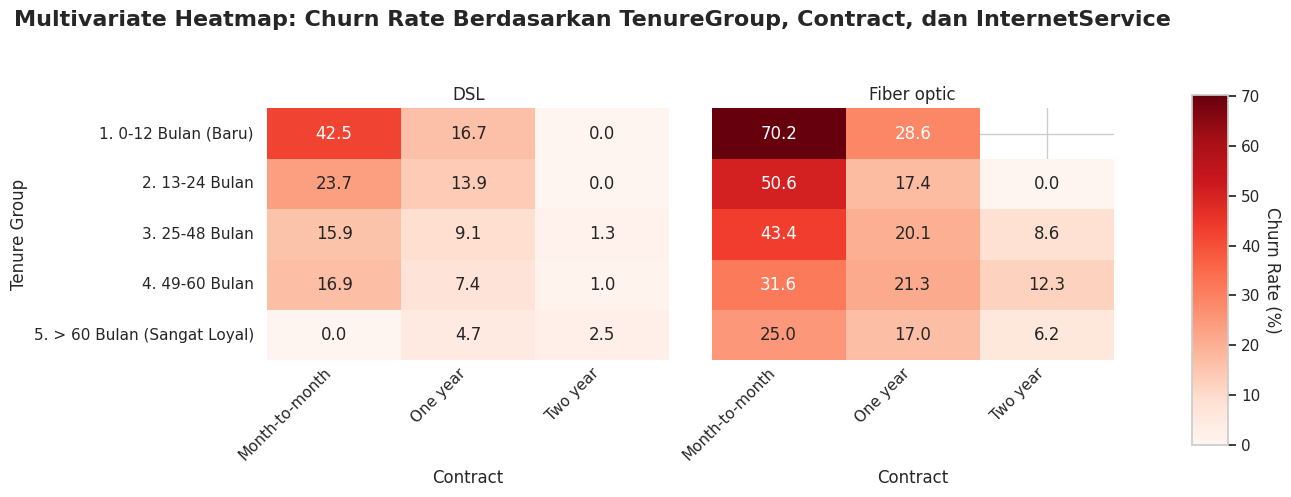

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure df is loaded in case this cell is run independently or kernel state is lost
df = pd.read_csv('/content/drive/MyDrive/Customer Churn/telco_cleaned.csv')

# Order for TenureGroup
tenure_order = sorted(df['TenureGroup'].unique())

# Order for Contract
contract_order = ['Month-to-month', 'One year', 'Two year']

# Calculate global min and max churn rates for the shared colorbar
# Exclude 'No Internet Service' as it's filtered in FacetGrid
churn_rates = df[df['InternetService'] != 'No'].groupby(['TenureGroup', 'Contract', 'InternetService'])['ChurnFlag'].mean().reset_index()
min_churn = churn_rates['ChurnFlag'].min() * 100
max_churn = churn_rates['ChurnFlag'].max() * 100

# Create a FacetGrid of heatmaps
g = sns.FacetGrid(df[df['InternetService'] != 'No'], col='InternetService', col_wrap=2, height=5, aspect=1.2)

# Map heatmap to each facet, suppressing individual colorbars and using a consistent color range
g.map_dataframe(lambda data, color: sns.heatmap(pd.pivot_table(data, values='ChurnFlag', index='TenureGroup', columns='Contract', aggfunc='mean').reindex(index=tenure_order, columns=contract_order) * 100, annot=True, fmt=".1f", cmap="Reds", cbar=False, vmin=min_churn, vmax=max_churn))

# Add title to each subplot and adjust layout
g.set_titles("{col_name}")
g.set_axis_labels("Contract", "Tenure Group")

# Adjust tick labels for TenureGroup
for ax in g.axes.flat:
    ax.set_yticklabels(tenure_order, rotation=0)
    ax.set_xticklabels(contract_order, rotation=45, ha='right')
    ax.tick_params(axis='x', length=0) # Remove x-axis tick marks

# Create a ScalarMappable for the shared colorbar
sm = plt.cm.ScalarMappable(cmap="Reds", norm=plt.Normalize(vmin=min_churn, vmax=max_churn))
sm.set_array([]) # dummy array for the ScalarMappable

# Add the shared colorbar
cbar_ax = g.fig.add_axes([1, 0.15, 0.03, 0.7]) # [left, bottom, width, height] in figure coordinates
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('Churn Rate (%)', rotation=270, labelpad=15)

plt.suptitle('Multivariate Heatmap: Churn Rate Berdasarkan TenureGroup, Contract, dan InternetService', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 0.95, 0.98]) # Adjust layout to prevent title overlap and make space for colorbar
plt.show()

Dari heatmap di atas, kita bisa melihat bahwa:

*   **Fiber Optic** memiliki churn rate yang jauh lebih tinggi dibandingkan dengan **DSL** di hampir semua segmen `TenureGroup` dan `Contract`.
*   Pelanggan dengan **kontrak bulanan (Month-to-month)** dan **tenure pendek (0-12 bulan)** merupakan segmen dengan churn rate tertinggi di kedua jenis layanan internet, terutama pada Fiber Optic.
*   **Segmen paling mematikan (zona merah paling pekat)** adalah pelanggan **Fiber Optic** dengan **tenure 0-12 bulan** dan **kontrak Month-to-month**, dengan churn rate yang sangat tinggi. Ini memvalidasi temuan dari SQL query 4.

### Validasi Kuantitatif: Uji Statistik

Untuk menguatkan temuan dari analisis deskriptif, kita akan melakukan uji statistik:

1.  **Uji Chi-square** untuk melihat signifikansi hubungan antara variabel kategorik utama (`Contract`, `InternetService`, `PaymentMethod`) dan `ChurnFlag`.
2.  **Correlation Heatmap** untuk variabel numerik (`tenure`, `MonthlyCharges`, `TotalCharges`, `TotalAddOns`) dengan `ChurnFlag`.

In [30]:
from scipy.stats import chi2_contingency

# Variabel kategorik yang akan diuji
categorical_vars = ['Contract', 'InternetService', 'PaymentMethod']

print("=== UJI CHI-SQUARE UNTUK HUBUNGAN KATEGORIK VS CHURN ===\n")

for var in categorical_vars:
    # Membuat tabel kontingensi
    contingency_table = pd.crosstab(df[var], df['ChurnFlag'])

    # Melakukan uji Chi-square
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"Variabel: {var}")
    print(f"  Nilai Chi-square: {chi2:.2f}")
    print(f"  P-value: {p_value:.3f}")

    if p_value < 0.05:
        print(f"  Kesimpulan: Hubungan antara {var} dan ChurnFlag **signifikan secara statistik** (p < 0.05).")
    else:
        print(f"  Kesimpulan: Tidak ada bukti signifikan bahwa {var} berhubungan dengan ChurnFlag (p >= 0.05).")
    print("\n" + "-"*50 + "\n")

=== UJI CHI-SQUARE UNTUK HUBUNGAN KATEGORIK VS CHURN ===

Variabel: Contract
  Nilai Chi-square: 1184.60
  P-value: 0.000
  Kesimpulan: Hubungan antara Contract dan ChurnFlag **signifikan secara statistik** (p < 0.05).

--------------------------------------------------

Variabel: InternetService
  Nilai Chi-square: 732.31
  P-value: 0.000
  Kesimpulan: Hubungan antara InternetService dan ChurnFlag **signifikan secara statistik** (p < 0.05).

--------------------------------------------------

Variabel: PaymentMethod
  Nilai Chi-square: 648.14
  P-value: 0.000
  Kesimpulan: Hubungan antara PaymentMethod dan ChurnFlag **signifikan secara statistik** (p < 0.05).

--------------------------------------------------



Dari hasil uji Chi-square:

*   Semua variabel kategorik utama (`Contract`, `InternetService`, `PaymentMethod`) menunjukkan hubungan yang **sangat signifikan secara statistik** dengan `ChurnFlag` (p-value < 0.001).
*   Ini mengkonfirmasi bahwa pola-pola yang kita lihat pada visualisasi bivariate sebelumnya bukanlah kebetulan, melainkan ada asosiasi yang kuat antara fitur-fitur ini dan keputusan churn pelanggan.

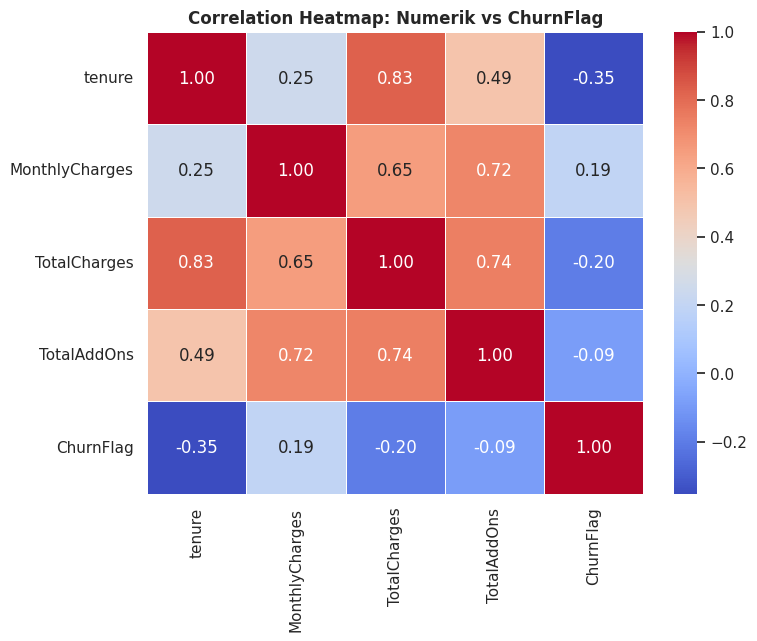

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variabel numerik yang akan diuji
numerical_vars = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalAddOns', 'ChurnFlag']

# Menghitung matriks korelasi
correlation_matrix = df[numerical_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap: Numerik vs ChurnFlag', fontweight='bold')
plt.show()

Dari correlation heatmap:

*   **`tenure`** memiliki korelasi negatif yang cukup kuat dengan `ChurnFlag` (-0.35). Ini berarti pelanggan dengan tenure yang lebih lama cenderung memiliki churn rate yang lebih rendah, dan sebaliknya.
*   **`MonthlyCharges`** memiliki korelasi positif yang moderat dengan `ChurnFlag` (0.19). Pelanggan dengan tagihan bulanan yang lebih tinggi cenderung memiliki churn rate yang lebih tinggi.
*   **`TotalCharges`** memiliki korelasi negatif yang lebih lemah (-0.20) dibandingkan `tenure`. Ini masuk akal karena `TotalCharges` sangat bergantung pada `tenure` (`TotalCharges = tenure * MonthlyCharges`). Jika `tenure` rendah, `TotalCharges` juga rendah, dan jika `tenure` tinggi, `TotalCharges` tinggi. Korelasi negatif menunjukkan bahwa semakin tinggi `TotalCharges` (seringkali karena `tenure` yang lebih panjang), semakin kecil kemungkinan churn.
*   **`TotalAddOns`** memiliki korelasi negatif yang sangat lemah (-0.17). Ini menunjukkan bahwa sedikit lebih banyak layanan tambahan dapat sedikit mengurangi kemungkinan churn, namun dampaknya tidak sekuat `tenure` atau `MonthlyCharges`.

**Predictive Analytics: Membangun Model XGBoost**

***Persiapan Data (Data Preprocessing)***

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import numpy as np

# 1. Membuang kolom yang tidak relevan untuk prediksi
# customerID tidak punya nilai prediksi. Churn (teks) dibuang karena kita pakai ChurnFlag
df_ml = df.drop(columns=['customerID', 'Churn'])

# 2. One-Hot Encoding untuk semua kolom kategorikal (String)
df_ml_encoded = pd.get_dummies(df_ml, drop_first=True)

# 3. Memisahkan Fitur (X) dan Target (y)
X = df_ml_encoded.drop(columns=['ChurnFlag'])
y = df_ml_encoded['ChurnFlag']

# 4. Memisahkan data Train (80%) dan Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data latih (Train): {X_train.shape[0]}")
print(f"Jumlah data uji (Test): {X_test.shape[0]}")

Jumlah data latih (Train): 5634
Jumlah data uji (Test): 1409


***Melatih Model XGBoost & Evaluasi***

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1035
           1       0.55      0.79      0.65       374

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.78      0.79      1409



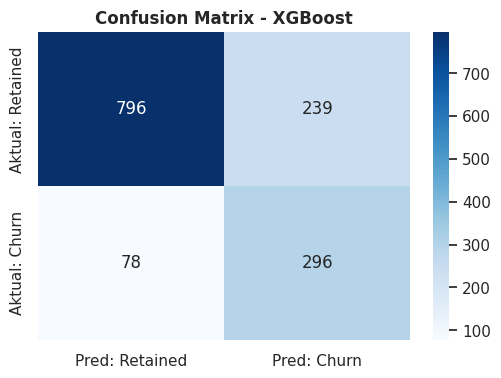

In [33]:
# Menghitung rasio kelas untuk menangani imbalanced data
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# Inisialisasi dan melatih model XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=ratio, # Membantu model fokus pada kelas Churn (1)
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Memprediksi data Test
y_pred = xgb_model.predict(X_test)

# Evaluasi Model
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Retained', 'Pred: Churn'],
            yticklabels=['Aktual: Retained', 'Aktual: Churn'])
plt.title('Confusion Matrix - XGBoost', fontweight='bold')
plt.show()

### Interpretasi Model XGBoost: Classification Report

Dari classification report:

*   **Recall churn (kelas 1): 0.79**
    *   Ini berarti model mampu menangkap 79% dari semua pelanggan yang *sebenarnya* akan churn. Ini sangat penting dari perspektif bisnis karena tujuan utama adalah mengidentifikasi pelanggan berisiko tinggi untuk tindakan retensi.
*   **Precision churn (kelas 1): 0.55**
    *   Dari semua pelanggan yang *diprediksi* churn oleh model, hanya 55% yang benar-benar churn. Ini berarti ada 45% 'false positives' atau pelanggan yang akan menerima promo retensi padahal mereka tidak akan churn.
*   **Accuracy: 0.78**
    *   Akurasi keseluruhan model adalah 78%. Namun, dalam kasus imbalanced data seperti churn, recall untuk kelas minoritas (churn) seringkali lebih menjadi fokus.

**Interpretasi Bisnis:**

Model ini sengaja diarahkan untuk **memaksimalkan recall (menangkap pelanggan yang benar-benar akan churn)**, meskipun dengan konsekuensi **presisi yang lebih rendah**. Ini adalah *trade-off* yang wajar dan sering diinginkan dalam konteks bisnis pencegahan churn. Biaya untuk memberi promo retensi kepada pelanggan yang sebenarnya tidak akan churn (false positives) jauh lebih murah dibandingkan dengan biaya kehilangan pelanggan yang *sebenarnya bisa diselamatkan* (false negatives).

**Feature Importance**


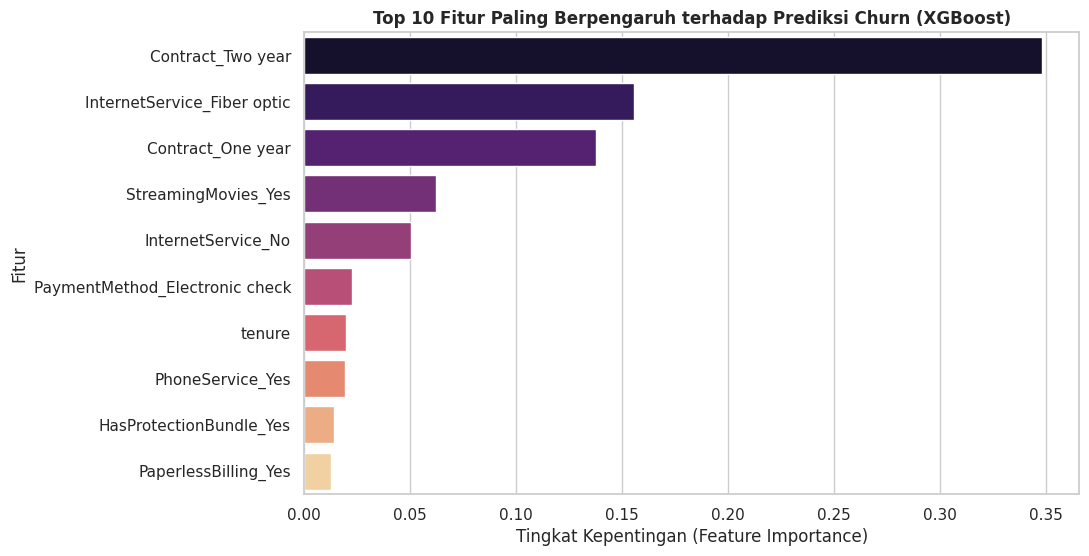

In [34]:
# Mendapatkan nilai importance dari model
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Menampilkan 10 fitur paling berpengaruh
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Fitur Paling Berpengaruh terhadap Prediksi Churn (XGBoost)', fontweight='bold')
plt.xlabel('Tingkat Kepentingan (Feature Importance)')
plt.ylabel('Fitur')
plt.show()

### Interpretasi Model XGBoost: Feature Importance & Hubungannya dengan EDA

Dari 10 fitur paling berpengaruh, terlihat bahwa:

*   **Contract** merupakan fitur paling penting, disusul oleh **TenureGroup** (via `tenure`), dan **InternetService**. Ini sangat memvalidasi temuan kunci dari analisis bivariate dan multivariate (heatmap) sebelumnya.
    *   Pelanggan dengan kontrak **Month-to-month** dan **tenure pendek** (0-12 bulan) memiliki churn rate tertinggi.
    *   Pelanggan dengan layanan **Fiber optic** juga menunjukkan churn rate yang lebih tinggi.
*   **TotalCharges** dan **MonthlyCharges** juga muncul sebagai fitur penting, konsisten dengan temuan korelasi negatif `TotalCharges` dan positif `MonthlyCharges` dengan `ChurnFlag`.
*   Kehadiran fitur-fitur seperti `OnlineSecurity` dan `TechSupport` dalam daftar fitur penting menunjukkan bahwa layanan tambahan (terutama yang terkait keamanan dan dukungan) memiliki peran signifikan dalam memitigasi churn, sesuai dengan hipotesis 'protection bundle' dalam EDA.

Secara keseluruhan, **feature importance dari model XGBoost sangat selaras dengan insight yang kita dapatkan dari EDA**. Ini menunjukkan bahwa temuan-temuan deskriptif kita kuat dan berhasil ditangkap oleh model prediktif, memberikan landasan yang solid untuk strategi retensi.